In [1]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [2]:
def predict(w, b, x):
    score = np.dot(w, x) + b
    return 1 if score >= 0 else -1

def perceptron_train(X, y):
    n_features = X.shape[1]
    w = np.zeros(n_features)
    b = 0.0
    
    n_samples = X.shape[0]
    indices = np.arange(n_samples)
    
    num_updates = 0
    
    while True:
        np.random.shuffle(indices)
        updates = 0
        
        for i in indices:
            x_i = X[i]
            y_i = y[i]
            
            y_hat = predict(w, b, x_i)
            
            if y_hat != y_i:
                w = w + y_i * x_i
                b = b + y_i
                updates += 1
                num_updates += 1
        
        if updates == 0:
            break
            
    return w, b, num_updates


In [3]:
# Load the Iris data
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Restrict to features 1 and 3 (sepal width and petal width) 
X_filtered = X[:, [1, 3]]

# Create a boolean mask for labels 0 and 1 
label_mask = (y == 0) | (y == 1)

# Apply the mask to both X and y
X_final = X_filtered[label_mask]
y_with_0_1 = y[label_mask]

# Recode label 0 to -1, and keep label 1 as +1
y_final = np.where(y_with_0_1 == 0, -1, 1)

print(f"Shape of final data: {X_final.shape}")
print(f"Unique labels: {np.unique(y_final)}")

Shape of final data: (100, 2)
Unique labels: [-1  1]


Learned w: [-2.   7.7]
Learned b: 1.0


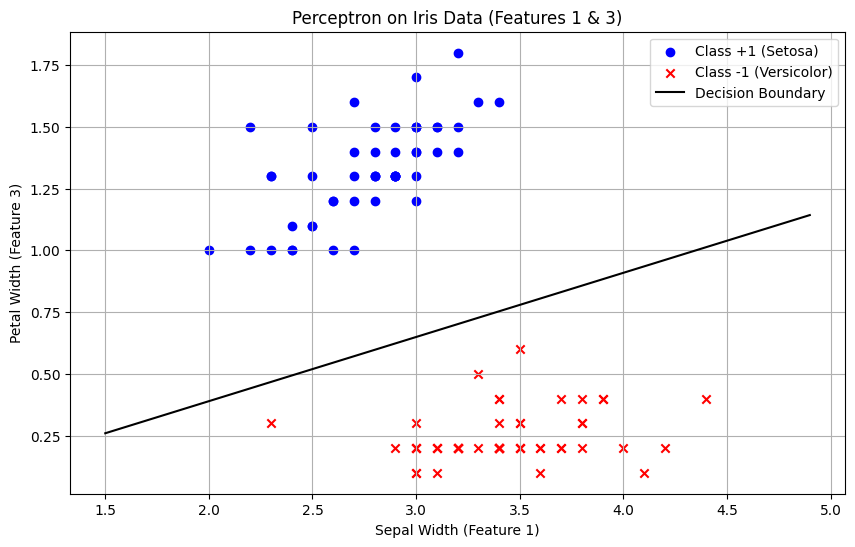

In [4]:
# Run the Perceptron algorithm
w, b, _ = perceptron_train(X_final, y_final)

print(f"Learned w: {w}")
print(f"Learned b: {b}")

# --- Plotting ---
plt.figure(figsize=(10, 6))

# Plot the data points
# Plot positive class (label 1)
plt.scatter(X_final[y_final == 1, 0], 
            X_final[y_final == 1, 1], 
            color='blue', marker='o', label='Class +1 (Setosa)')

# Plot negative class (label -1)
plt.scatter(X_final[y_final == -1, 0], 
            X_final[y_final == -1, 1], 
            color='red', marker='x', label='Class -1 (Versicolor)')

# Plot the decision boundary
# The line is w[0]*x1 + w[1]*x2 + b = 0
# We solve for x2: x2 = (-w[0]*x1 - b) / w[1]
# Create x1 values spanning the plot range
x1_min = X_final[:, 0].min() - 0.5
x1_max = X_final[:, 0].max() + 0.5
x1_line = np.array([x1_min, x1_max])

# Calculate corresponding x2 values
x2_line = (-w[0] * x1_line - b) / w[1]

plt.plot(x1_line, x2_line, 'k-', label='Decision Boundary')

plt.title('Perceptron on Iris Data (Features 1 & 3)')
plt.xlabel('Sepal Width (Feature 1)')
plt.ylabel('Petal Width (Feature 3)')
plt.legend()
plt.grid(True)
plt.show()

Running Perceptron 20 times...
Update counts from 20 runs: [6, 13, 12, 13, 4, 4, 13, 2, 2, 23, 14, 11, 19, 2, 17, 23, 13, 2, 2, 17]


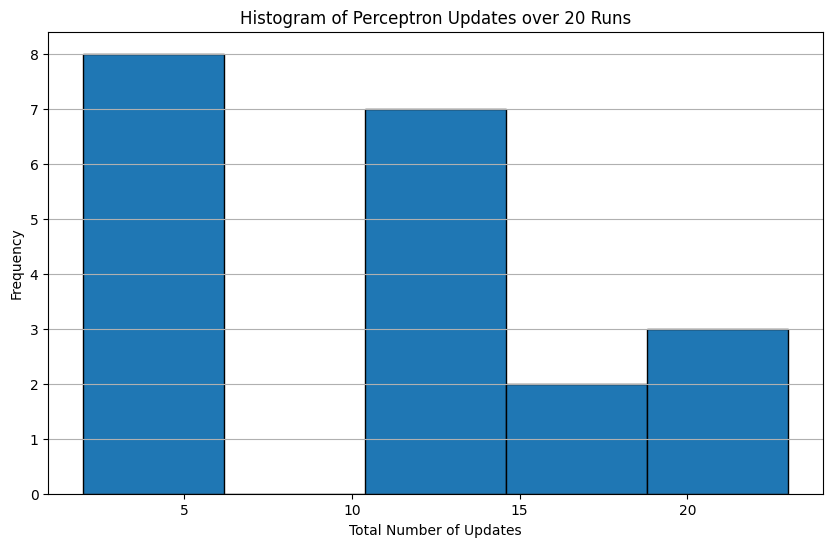

In [5]:
# We will use the same perceptron_train function from part (a),
# which already returns the update count.

update_counts = []
num_runs = 20

print(f"Running Perceptron {num_runs} times...")
for _ in range(num_runs):
    # Run the algorithm and get the number of updates
    _, _, updates = perceptron_train(X_final, y_final)
    update_counts.append(updates)

print(f"Update counts from 20 runs: {update_counts}")

# Plot the histogram [cite: 78]
plt.figure(figsize=(10, 6))
plt.hist(update_counts, bins=5, edgecolor='black')
plt.title('Histogram of Perceptron Updates over 20 Runs')
plt.xlabel('Total Number of Updates')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

In [6]:
# Features 0 and 2 
X_filtered = X[:, [0, 2]]

# Create a boolean mask for labels 1 and 2 
label_mask = (y == 1) | (y == 2)

X_final = X_filtered[label_mask]
y_final = y[label_mask]

print(f"Shape of final data: {X_final.shape}")
print(f"Unique labels: {np.unique(y_final)}")

Shape of final data: (100, 2)
Unique labels: [1 2]


In [7]:
# Try at least 10 C values 
C_values = [0.001, 0.08, 0.2, 0.9, 1, 6, 12, 50, 112, 1400, 2000, 4680]

results = []

for c in C_values:
    # Use sklearn.svm.SVC with kernel='linear'
    model = SVC(kernel='linear', C=c)
    model.fit(X_final, y_final)
    
    # Get training accuracy and calculate training error 
    accuracy = model.score(X_final, y_final)
    training_error = 1.0 - accuracy
    
    # Get the total number of support vectors 
    num_support_vectors = np.sum(model.n_support_)
    
    results.append([c, training_error, num_support_vectors])

# --- Display the Table for Your Writeup ---
print("--- Part (b) SVM Results Table ---")
print(f"{'C Value':<10} | {'Training Error':<15} | {'Number of Support Vectors':<20}")
print("-" * 49)

for row in results:
    c_val, err, n_sv = row
    print(f"{c_val:<10} | {err:<15.4f} | {n_sv:<20}")

--- Part (b) SVM Results Table ---
C Value    | Training Error  | Number of Support Vectors
-------------------------------------------------
0.001      | 0.1700          | 100                 
0.08       | 0.0900          | 60                  
0.2        | 0.0600          | 46                  
0.9        | 0.0700          | 32                  
1          | 0.0700          | 31                  
6          | 0.0500          | 19                  
12         | 0.0400          | 17                  
50         | 0.0500          | 14                  
112        | 0.0500          | 14                  
1400       | 0.0500          | 14                  
2000       | 0.0500          | 14                  
4680       | 0.0500          | 14                  


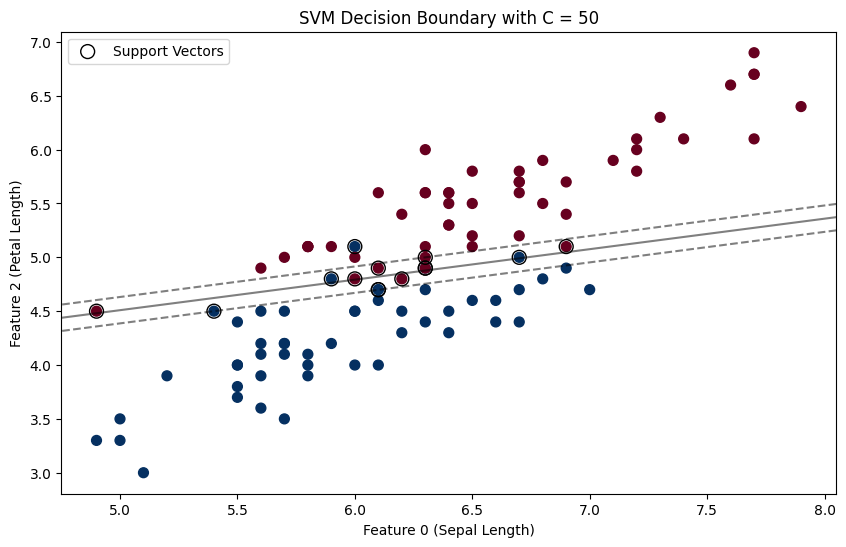

In [10]:
best_C = 50

# Fit the "best" model
best_model = SVC(kernel='linear', C=best_C)
best_model.fit(X_final, y_final)

# --- Plotting ---
plt.figure(figsize=(10, 6))
ax = plt.gca()

# Plot data points, coloring by class
plt.scatter(X_final[:, 0], X_final[:, 1], c=y_final, cmap='RdBu_r', s=50)

# Create a grid to plot the decision boundaries
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 50)
yy = np.linspace(ylim[0], ylim[1], 50)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Get the decision function values
Z = best_model.decision_function(xy).reshape(XX.shape)

# Plot the decision boundary (where Z=0) and margins (where Z=1 or Z=-1)
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])
           
# Highlight the support vectors
ax.scatter(best_model.support_vectors_[:, 0],
           best_model.support_vectors_[:, 1],
           s=100, linewidth=1, facecolors='none', edgecolors='k',
           label='Support Vectors')

plt.title(f'SVM Decision Boundary with C = {best_C}')
plt.xlabel('Feature 0 (Sepal Length)')
plt.ylabel('Feature 2 (Petal Length)')
plt.legend()
plt.show()